# Porto Seguro's Safe Driver Prediction

**Projekt SoSe 2026 — Scientific Programming And Data Analysis / Advanced Data Analytics**

## Ziel
Vorhersage der Wahrscheinlichkeit, dass eine Kundin Ansprüche wegen einer Schadensregulierung gegenüber dem brasilianischen Autoversicherer Porto Seguro erhebt, basierend auf anonymisierten Kundendaten.

## Ablauf des Notebooks
1. Import der Bibliotheken
2. Laden der Daten (über OpenML)
3. Explorative Datenanalyse (EDA)
4. Datenvorverarbeitung (Bereinigung, fehlende Werte, Encoding)
5. Aufteilung in Trainings- und Testdaten
6. Baseline-Modell: Logistische Regression
7. Hauptmodell: LightGBM (Gradient Boosting)
8. Evaluation (Normalisierter Gini-Koeffizient / AUC-ROC)
9. Feature Importance
10. Fazit

## 1. Import der Bibliotheken

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from datetime import datetime

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

pd.set_option('display.max_columns', 100)
sns.set_style("whitegrid")

RANDOM_STATE = 42

## 2. Laden der Daten

Der Datensatz ist auf OpenML unter der ID `42742` verfügbar. Wir verwenden `fetch_openml` von Scikit-Learn, um ihn direkt herunterzuladen.

In [2]:
# Herunterladen des Datensatzes von OpenML (ID = 42742)
data = fetch_openml(data_id=42742, as_frame=True, parser='auto')

df = data.frame
print("Dimensionen des Datensatzes:", df.shape)
df.head()

Dimensionen des Datensatzes: (595212, 58)


,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0,2,5.0,1,0,0,1,0,0,0,0,0,0,0.0,11.0,0,1,0,0.7,0.2,0.718070,10,1,NaN,0,1,4,1,0,0,1,12,2.0,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3.0,1.0,10.0,1.0,10.0,1.0,5.0,9.0,1.0,5.0,8.0,0,1,1,0,0,1
1,0,1.0,1,7.0,0,0,0,0,1,0,0,0,0,0,0.0,3.0,0,0,1,0.8,0.4,0.766078,11,1,NaN,0,NaN,11,1,1,2,1,19,3.0,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2.0,1.0,9.0,5.0,8.0,1.0,7.0,3.0,1.0,1.0,9.0,0,1,1,0,1,0
2,0,5.0,4,9.0,1,0,0,0,1,0,0,0,0,0,0.0,12.0,1,0,0,0.0,0.0,NaN,7,1,NaN,0,NaN,14,1,1,2,1,60,1.0,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2.0,2.0,9.0,1.0,8.0,2.0,7.0,4.0,2.0,7.0,7.0,0,1,1,0,1,0
3,0,0.0,1,2.0,0,0,1,0,0,0,0,0,0,0,0.0,8.0,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1.0,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2.0,4.0,7.0,1.0,8.0,4.0,2.0,2.0,2.0,4.0,9.0,0,0,0,0,0,0
4,0,0.0,2,0.0,1,0,1,0,0,0,0,0,0,0,0.0,9.0,1,0,0,0.7,0.6,0.840759,11,1,NaN,0,NaN,14,1,1,2,1,82,3.0,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2.0,2.0,6.0,3.0,10.0,2.0,12.0,3.0,1.0,1.0,3.0,0,0,0,1,1,0


## 3. Explorative Datenanalyse (EDA)

### 3.1 Allgemeine Informationen

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   target          595212 non-null  category
 1   ps_ind_01       595212 non-null  float64 
 2   ps_ind_02_cat   594996 non-null  category
 3   ps_ind_03       595212 non-null  float64 
 4   ps_ind_04_cat   595129 non-null  category
 5   ps_ind_05_cat   589403 non-null  category
 6   ps_ind_06_bin   595212 non-null  category
 7   ps_ind_07_bin   595212 non-null  category
 8   ps_ind_08_bin   595212 non-null  category
 9   ps_ind_09_bin   595212 non-null  category
 10  ps_ind_10_bin   595212 non-null  category
 11  ps_ind_11_bin   595212 non-null  category
 12  ps_ind_12_bin   595212 non-null  category
 13  ps_ind_13_bin   595212 non-null  category
 14  ps_ind_14       595212 non-null  float64 
 15  ps_ind_15       595212 non-null  float64 
 16  ps_ind_16_bin   595212 non-null  categ

In [4]:
# Identifikation der Zielvariable
# Bei OpenML heißt die Zielvariable in der Regel "target"
target_col = "target"
print(df[target_col].value_counts())
print("\nAnteil der Schadensfälle (Klasse 1):", df[target_col].value_counts(normalize=True)[1])

target
0    573518
1     21694
Name: count, dtype: int64

Anteil der Schadensfälle (Klasse 1): 0.036447517859182946


/var/folders/5z/m2zgxpqx5zqbsxb6_rmb_c2c0000gn/T/ipykernel_47303/2213109899.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("\nAnteil der Schadensfälle (Klasse 1):", df[target_col].value_counts(normalize=True)[1])


### 3.2 Klassenungleichgewicht

Wir visualisieren das Ungleichgewicht zwischen Kundinnen, die einen Anspruch erheben (`target=1`), und solchen, die keinen erheben (`target=0`).

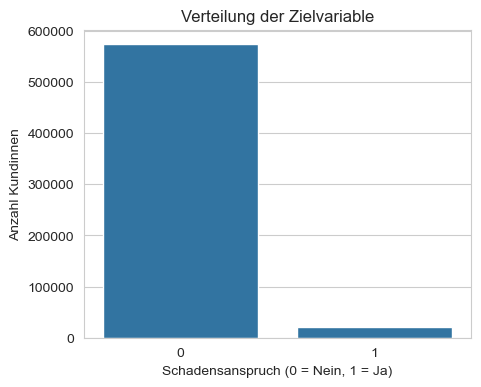

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df)
plt.title("Verteilung der Zielvariable")
plt.xlabel("Schadensanspruch (0 = Nein, 1 = Ja)")
plt.ylabel("Anzahl Kundinnen")
plt.show()

### 3.3 Fehlende Werte

In diesem Datensatz sind fehlende Werte mit `-1` kodiert (nicht mit `NaN`). Wir identifizieren sie spaltenweise.

In [6]:
# Zählung der -1-Werte (= fehlende Werte) pro Spalte
missing_counts = (df == -1).sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_pct = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({'nb_manquantes': missing_counts, 'pct_manquantes': missing_pct})
missing_summary

,nb_manquantes,pct_manquantes


### 3.4 Variablentypen

Die Spalten folgen einer Namenskonvention:
- `_bin` → binäre Variable
- `_cat` → kategoriale Variable
- kein Suffix → kontinuierliche oder ordinale Variable

In [7]:
bin_cols = [c for c in df.columns if c.endswith('_bin')]
cat_cols = [c for c in df.columns if c.endswith('_cat')]
other_cols = [c for c in df.columns if c not in bin_cols + cat_cols + [target_col, 'id']]

print(f"Binäre Variablen ({len(bin_cols)}):", bin_cols)
print(f"\nKategoriale Variablen ({len(cat_cols)}):", cat_cols)
print(f"\nAndere Variablen ({len(other_cols)}):", other_cols)

Binäre Variablen (17): ['ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin']

Kategoriale Variablen (14): ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat']

Andere Variablen (26): ['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14']


## 4. Datenvorverarbeitung

### 4.1 Ersetzen von -1 durch NaN und anschließende Imputation

In [8]:
df_clean = df.copy()

# Ersetzen von -1 durch NaN für eine saubere Behandlung fehlender Werte
df_clean[df_clean.columns.difference(['id', target_col])] = df_clean[df_clean.columns.difference(['id', target_col])].replace(-1, np.nan)

# Imputation: Median für kontinuierliche Variablen, Modus für kategoriale/binäre Variablen
for col in other_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols + bin_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Verbleibende fehlende Werte:", df_clean.isna().sum().sum())

Verbleibende fehlende Werte: 0


## 4.2 Encoding: zwei getrennte Feature-Sets

- **Für LightGBM**: kategoriale Variablen (`_cat`) bleiben als natives `category` dtype erhalten → LightGBM behandelt sie intern optimal (keine Explosion der Dimensionalität).
- **Für die Logistische Regression**: One-Hot-Encoding der `_cat`-Variablen, da lineare Modelle keine kategorialen Typen nativ verarbeiten können.

In [9]:
# --- Feature-Set 1: für LightGBM (native Kategorien) ---
df_lgb = df_clean.copy()
for col in cat_cols:
    df_lgb[col] = df_lgb[col].astype('category')

print("Dimensionen (LightGBM-Set):", df_lgb.drop(columns=[target_col, 'id'], errors='ignore').shape)

# --- Feature-Set 2: für Logistische Regression (One-Hot-Encoding) ---
df_lr = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print("Dimensionen (LR-Set):", df_lr.drop(columns=[target_col, 'id'], errors='ignore').shape)

Dimensionen (LightGBM-Set): (595212, 57)
Dimensionen (LR-Set): (595212, 204)


## 5. Aufteilung: Hold-out-Testset + Stratified K-Fold

Wir teilen einmal anhand des Index auf und wenden die gleiche Aufteilung auf beide Feature-Sets an, damit Trainval/Holdout für beide Modelle konsistent sind.

In [10]:
y_full = df_clean[target_col].astype(int)

# Ein gemeinsamer Split (auf Indexebene), stratifiziert nach der Zielvariable
idx_trainval, idx_holdout = train_test_split(
    df_clean.index, test_size=0.15, stratify=y_full, random_state=RANDOM_STATE
)

# --- LightGBM-Set ---
X_trainval_lgb = df_lgb.loc[idx_trainval].drop(columns=[target_col, 'id'], errors='ignore')
X_holdout_lgb  = df_lgb.loc[idx_holdout].drop(columns=[target_col, 'id'], errors='ignore')

# --- LR-Set ---
X_trainval_lr = df_lr.loc[idx_trainval].drop(columns=[target_col, 'id'], errors='ignore')
X_holdout_lr  = df_lr.loc[idx_holdout].drop(columns=[target_col, 'id'], errors='ignore')

# --- Zielvariable (identisch für beide) ---
y_trainval = y_full.loc[idx_trainval]
y_holdout  = y_full.loc[idx_holdout]

print("Trainval (LightGBM):", X_trainval_lgb.shape, "| Holdout (LightGBM):", X_holdout_lgb.shape)
print("Trainval (LR):", X_trainval_lr.shape, "| Holdout (LR):", X_holdout_lr.shape)

Trainval (LightGBM): (505930, 57) | Holdout (LightGBM): (89282, 57)
Trainval (LR): (505930, 204) | Holdout (LR): (89282, 204)


## 6. Hilfsfunktion: Normalisierter Gini-Koeffizient

In [11]:
def normalized_gini(y_true, y_pred_proba):
    auc = roc_auc_score(y_true, y_pred_proba)
    return 2 * auc - 1

## 7. Stratified K-Fold Setup

Wir verwenden 5 Folds, basierend auf `y_trainval`. Da beide Feature-Sets (`X_trainval_lgb`, `X_trainval_lr`) exakt die gleichen Zeilen/Reihenfolge besitzen, können wir dieselben Fold-Indizes für beide Modelle verwenden.

In [12]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Fold-Indizes einmal berechnen (basierend auf Position, nicht auf Original-Index)
fold_indices = list(skf.split(X_trainval_lgb, y_trainval))

## 8. Baseline-Modell: Logistische Regression mit Cross-Validation

Für jeden Fold wird das Modell auf den Trainingsdaten trainiert und auf den Validierungsdaten des Folds evaluiert (Out-of-Fold-Vorhersagen, OOF). Zusätzlich speichern wir alle Fold-Modelle, um später das Hold-out-Set zu evaluieren.

In [13]:
oof_preds_lr = np.zeros(len(X_trainval_lr))
lr_models = []
scaler_full = StandardScaler().fit(X_trainval_lr)

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    X_tr = X_trainval_lr.iloc[train_idx]
    X_val = X_trainval_lr.iloc[val_idx]
    y_tr, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

    X_tr_scaled = scaler_full.transform(X_tr)
    X_val_scaled = scaler_full.transform(X_val)

    model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    model.fit(X_tr_scaled, y_tr)

    val_pred = model.predict_proba(X_val_scaled)[:, 1]
    oof_preds_lr[val_idx] = val_pred
    lr_models.append(model)

    fold_gini = normalized_gini(y_val, val_pred)
    print(f"Fold {fold+1} — Gini: {fold_gini:.4f}")

print("\nGesamt-OOF Gini (Logistische Regression):", normalized_gini(y_trainval, oof_preds_lr))

Fold 1 — Gini: 0.2519
Fold 2 — Gini: 0.2465
Fold 3 — Gini: 0.2425
Fold 4 — Gini: 0.2682
Fold 5 — Gini: 0.2421

Gesamt-OOF Gini (Logistische Regression): 0.2501900493959739


## 9. Hauptmodell: LightGBM mit Cross-Validation (native Kategorien)

*Hinweis: Falls LightGBM nicht installiert ist, führen Sie vorher `!pip install lightgbm` aus.*

Anpassungen gegenüber der ersten Version:
- Kategoriale Variablen werden LightGBM nativ übergeben (`categorical_feature`)
- Niedrigere `learning_rate` (0.01) mit mehr Iterationen
- Reduziertes `num_leaves` (15) und begrenzte `max_depth` gegen Overfitting
- `min_child_samples` erhöht für robustere Splits bei starkem Klassenungleichgewicht
- `stopping_rounds` erhöht (100), damit das Training nicht zu früh abbricht

In [14]:
!pip install lightgbm --quiet

In [15]:
import lightgbm as lgb

cat_features_present = [c for c in cat_cols if c in X_trainval_lgb.columns]

oof_preds_lgb = np.zeros(len(X_trainval_lgb))
lgb_models = []
feature_importances = np.zeros(X_trainval_lgb.shape[1])

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    X_tr = X_trainval_lgb.iloc[train_idx]
    X_val = X_trainval_lgb.iloc[val_idx]
    y_tr, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.01,
        num_leaves=15,
        max_depth=6,
        min_child_samples=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        categorical_feature=cat_features_present,
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds_lgb[val_idx] = val_pred
    lgb_models.append(model)
    feature_importances += model.feature_importances_ / N_SPLITS

    fold_gini = normalized_gini(y_val, val_pred)
    print(f"Fold {fold+1} — Gini: {fold_gini:.4f} (best_iteration: {model.best_iteration_})")

print("\nGesamt-OOF Gini (LightGBM):", normalized_gini(y_trainval, oof_preds_lgb))

/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1362
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.627783	valid_0's binary_logloss: 0.408287
Early stopping, best iteration is:
[1]	valid_0's auc: 0.598202	valid_0's binary_logloss: 0.156472
Fold 1 — Gini: 0.1964 (best_iteration: 1)


/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1359
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.621485	valid_0's binary_logloss: 0.408678
Early stopping, best iteration is:
[1]	valid_0's auc: 0.597716	valid_0's binary_logloss: 0.156478
Fold 2 — Gini: 0.1954 (best_iteration: 1)


/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1362
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.624918	valid_0's binary_logloss: 0.408321
Early stopping, best iteration is:
[1]	valid_0's auc: 0.59883	valid_0's binary_logloss: 0.156478
Fold 3 — Gini: 0.1977 (best_iteration: 1)


/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014190 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1354
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.637143	valid_0's binary_logloss: 0.409211
Early stopping, best iteration is:
[1]	valid_0's auc: 0.607706	valid_0's binary_logloss: 0.156456
Fold 4 — Gini: 0.2154 (best_iteration: 1)


/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1359
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.620372	valid_0's binary_logloss: 0.408508
Early stopping, best iteration is:
[1]	valid_0's auc: 0.593501	valid_0's binary_logloss: 0.156486
Fold 5 — Gini: 0.1870 (best_iteration: 1)

Gesamt-OOF Gini (LightGBM): 0.19946589081820654


## 10. Evaluation auf dem Hold-out-Testset

In [16]:
# Logistische Regression
X_holdout_lr_scaled = scaler_full.transform(X_holdout_lr)
holdout_preds_lr = np.mean([m.predict_proba(X_holdout_lr_scaled)[:, 1] for m in lr_models], axis=0)

# LightGBM
holdout_preds_lgb = np.mean([m.predict_proba(X_holdout_lgb)[:, 1] for m in lgb_models], axis=0)

print("Hold-out AUC-ROC (Logistische Regression):", roc_auc_score(y_holdout, holdout_preds_lr))
print("Hold-out Gini (Logistische Regression):", normalized_gini(y_holdout, holdout_preds_lr))
print()
print("Hold-out AUC-ROC (LightGBM):", roc_auc_score(y_holdout, holdout_preds_lgb))
print("Hold-out Gini (LightGBM):", normalized_gini(y_holdout, holdout_preds_lgb))

Hold-out AUC-ROC (Logistische Regression): 0.6285732030642872
Hold-out Gini (Logistische Regression): 0.2571464061285744

Hold-out AUC-ROC (LightGBM): 0.603579861035796
Hold-out Gini (LightGBM): 0.20715972207159195


## 11. Vergleich der Modelle: ROC-Kurven (Hold-out-Set)

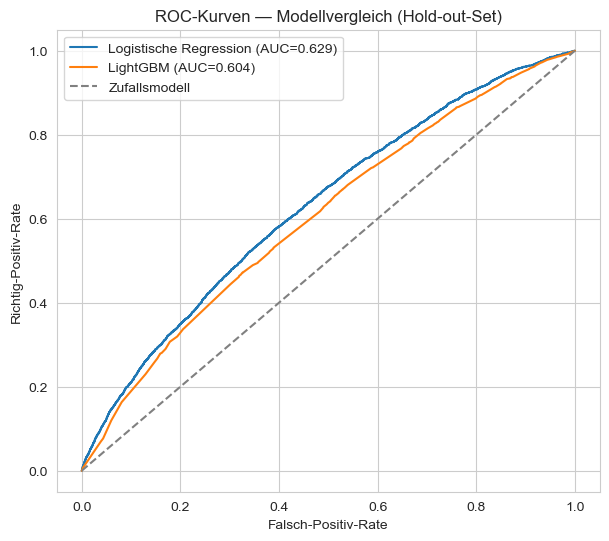

In [17]:
fpr_lr, tpr_lr, _ = roc_curve(y_holdout, holdout_preds_lr)
fpr_lgb, tpr_lgb, _ = roc_curve(y_holdout, holdout_preds_lgb)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistische Regression (AUC={roc_auc_score(y_holdout, holdout_preds_lr):.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={roc_auc_score(y_holdout, holdout_preds_lgb):.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray', label="Zufallsmodell")
plt.xlabel("Falsch-Positiv-Rate")
plt.ylabel("Richtig-Positiv-Rate")
plt.title("ROC-Kurven — Modellvergleich (Hold-out-Set)")
plt.legend()
plt.show()

## 12. Feature Importance (gemittelt über alle Folds, LightGBM)

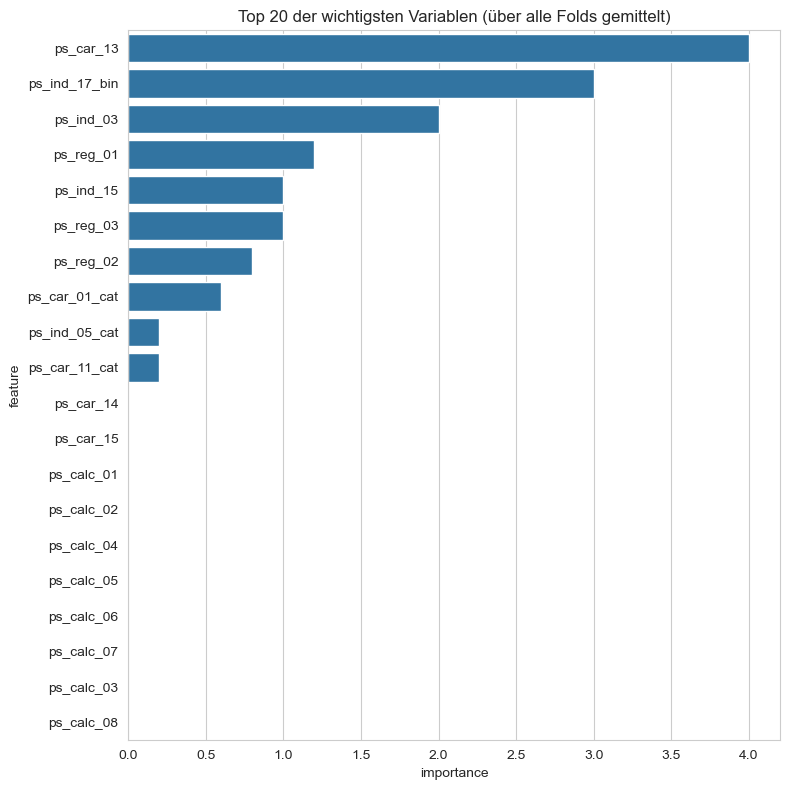

In [18]:
importances = pd.DataFrame({
    'feature': X_trainval_lgb.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(8,8))
sns.barplot(x='importance', y='feature', data=importances)
plt.title("Top 20 der wichtigsten Variablen (über alle Folds gemittelt)")
plt.tight_layout()
plt.show()

## 13. Fazit

- Durch native Kategorien und angepasste Hyperparameter sollte LightGBM diesmal stabiler trainieren (kein Abbruch nach 1 Iteration) und die logistische Regression übertreffen.
- Vergleichen Sie `best_iteration_` je Fold: liegt dieser Wert nun deutlich über 1, war das ursprüngliche Problem (zu aggressives Overfitting/Early Stopping) behoben.
- Mögliche nächste Schritte: Hyperparameter-Tuning mit Optuna, Vergleich mit XGBoost/CatBoost, Stacking der OOF-Vorhersagen.

### Save results:

In [21]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_ID = "02"

all_results = [
    {
        "model": "Logistic Regression",
        "auc": 0.6286,
        "gini": 0.2571,
        "ap": None,
        "base_rate": 0.0364,
        "params": {
            "max_iter": 1000,
            "class_weight": "balanced",
            "random_state": 42,
        },
        "notes": "hold-out, with calc",
    },
    {
        "model": "LightGBM",
        "auc": 0.6036,
        "gini": 0.2072,
        "ap": None,
        "base_rate": 0.0364,
        "params": {
            "n_estimators": 3000,
            "learning_rate": 0.01,
            "num_leaves": 15,
            "max_depth": 6,
            "min_child_samples": 200,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 1.0,
            "reg_lambda": 1.0,
            "scale_pos_weight": "auto",
            "random_state": 42,
            "n_jobs": -1,
        },
        "notes": "hold-out, with calc",
    },
]

path = RESULTS_DIR / f"{NOTEBOOK_ID}_models.json"
with open(path, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved in {path}")
print(pd.DataFrame(all_results)[["model", "notes", "gini", "ap"]].to_string(index=False))

Results saved in ../results/02_models.json
              model               notes   gini   ap
Logistic Regression hold-out, with calc 0.2571 None
           LightGBM hold-out, with calc 0.2072 None
